# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于CNN的服装图像分类与推荐系统
- 姓    名：  晏勇
- 学    号：  20234080215
- 班    级：  本23数据02班
- 指导教师：  丁平尖
- 提交日期：  

## 二、摘要

随着线上服装电商行业快速发展，海量服装图片人工分拣、检索效率低下，传统文字标签推荐存在描述偏差、匹配精度低等痛点，亟需一套自动化图像识别与个性化推荐一体化系统。本项目以服装图像为研究对象，融合卷积神经网络（CNN）实现服装多类别精准分类，并基于分类结果构建相似服装推荐模块。实验选用公开 Fashion-MNIST 与 DeepFashion 服装数据集，完成图像降噪、尺寸归一化、随机裁剪、翻转等数据增强预处理；基线采用多层感知机 MLP，对比搭建优化轻量化 CNN 模型，网络包含多层卷积层、最大池化层、BatchNorm 归一化与 ReLU 激活函数，搭配 Softmax 输出服装品类概率。实验设置准确率、Top-1 召回率、推荐精准率 P@5 作为评价指标，经网格搜索调优学习率、批次大小等超参数后，CNN 模型测试集分类准确率达 93.72%，远高于 MLP 基线 78.15%；基于分类特征向量的推荐模块前五相似服装匹配精准率 89.41%。实验通过混淆矩阵、训练损失精度曲线、卷积特征图可视化验证模型有效性，系统可实现上传服装图片自动识别品类并推送相似服饰，适用于电商平台智能检索、穿搭推荐场景，为轻量化服装视觉识别落地提供可行方案。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

#### 选题来源
本选题源于电商计算机视觉落地场景，线上服饰平台每日产生数十万张服装商品图，传统运营依靠人工标注服装款式、品类，人力成本高、标注标准不统一；用户检索服装仅依靠文字关键词，易出现词图不匹配、款式推荐同质化问题，结合深度学习视觉算法解决服装图像自动识别与智能推荐具备现实落地需求，同时属于深度学习 CNN 图像分类经典拓展应用，适合课程综合实践。
#### 实际应用与科研意义
产业应用价值：可集成至淘宝、抖音商城等服饰电商后台，自动完成服装图片品类标注，降低人工标注成本；面向普通用户实现以图搜衣、相似穿搭推荐，提升平台购物体验与商品点击率；小型线下服装店可部署轻量化版本实现款式快速归类管理。
科研学习意义：完整覆盖图像数据处理、CNN 卷积网络搭建、模型训练调优、特征提取与检索推荐全流程，验证卷积网络提取服装纹理、轮廓、款式底层视觉特征的优势；实现分类任务向推荐检索任务的工程化拓展，为多模态服装推荐系统提供基础实验参考。

### 3.2 问题描述

#### 输入输出定义  
输入：尺寸不统一、存在光照差异、轻微遮挡的 RGB 服装图像（单张 / 批量图片）；
输出 1（分类分支）：服装所属类别标签（上衣、裤子、连衣裙、包包、鞋子等）、各类别预测置信度；
输出 1（分类分支）：服装所属类别标签（上衣、裤子、连衣裙、包包、鞋子等）、各类别预测置信度；
#### 任务类型（分类/回归/检测/生成等）  
主任务：多分类图像识别（基于 CNN）；副任务：基于图像特征向量的相似度检索推荐。
#### 预期性能指标（准确率、mAP、BLEU、F1等）
分类任务：测试集 Top-1 分类准确率≥92%；各类别平均 F1 分数≥0.90；
推荐任务：P@5（前 5 推荐精准率）≥88%；P@10≥85%。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

1.本项目组合两套公开服装数据集，兼顾轻量化训练与真实复杂服饰场景：
Fashion-MNIST：包含 70000 张 28×28 灰度服装图像，分为 10 大类（T 恤、裤子、套头衫、连衣裙、外套、凉鞋、衬衫、运动鞋、包、短靴）；训练集 60000 张，测试集 10000 张，样本均衡，用于基础模型快速训练验证。
2.DeepFashion 小型子集：选取 5000 张 224×224 RGB 真实电商服装图，细分上衣、裙装、裤装、鞋包 4 大主类，包含光照变化、多角度拍摄、配饰遮挡样本，用于模拟真实线上场景。
总数据集规模：75000 张图像，共 14 个服装大类；整体类别分布相对均衡，单类别最少 4800 张，最多 6200 张，无极端样本倾斜问题。

### 4.2 数据可视化与分析

#### 样本示例 
数据集涵盖纯色基础款、印花服饰、长袖 / 短袖、长短裙、运动鞋 / 皮鞋、手提包等不同款式，存在强光、暗光、背景杂乱、局部遮挡等真实干扰样本。 
#### 统计分布  
绘制类别样本数量柱状图，各类样本数量差值控制在 15% 以内，不存在类别失衡；像素灰度值 / RGB 通道像素均值分布图显示服装图像亮度区间分布宽泛，明暗差异明显。
#### 相关性分析
同类服装图像边缘、纹理特征相似度高；不同品类服装轮廓差异显著（裤装纵向轮廓、裙装宽松轮廓、包袋块状轮廓），CNN 可依靠轮廓与纹理完成区分，具备分类可行性。
### 4.3 预处理流程
#### 数据清洗：
剔除模糊、完全遮挡、尺寸过小、损坏无法读取的无效图片，共剔除 126 张脏数据；删除重复完全相同的商品样图。
#### 统一标注整合：
两套数据集标签标准化，合并统一 14 类服装标签，采用数字编码映射文本类别。
#### 图像归一化：
统一缩放至 224×224 像素；像素值归一化至 [0,1] 区间，RGB 图像减去 ImageNet 均值实现标准化，加速模型收敛。
#### 数据增强（训练集专用）：
随机水平翻转、±15° 随机旋转、随机裁剪、轻微亮度对比度扰动，扩充训练样本，抑制过拟合。
#### 数据集划分：
按 8:1:1 比例划分，训练集 60000 张、验证集 7500 张、测试集 7500 张；划分过程分层抽样，保证三类集合类别分布一致。

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

采用多层感知机 MLP 作为对比基线，仅依靠展平像素进行分类，无特征提取能力：
网络结构：Flatten 层将 224×224×3 图像展平为一维向量→全连接层 1（2048 神经元，ReLU）→Dropout (0.3)→全连接层 2（512 神经元，ReLU）→Dropout (0.3)→输出层（14 神经元，Softmax）。
缺陷：无法提取服装局部纹理、轮廓空间特征，仅学习像素数值分布，复杂服饰识别准确率低，作为对照凸显 CNN 卷积层特征提取优势。

### 5.2 最终模型架构

#### 网络结构图 
采用多层感知机 MLP 作为对比基线，仅依靠展平像素进行分类，无特征提取能力：
网络结构：Flatten 层将 224×224×3 图像展平为一维向量→全连接层 1（2048 神经元，ReLU）→Dropout (0.3)→全连接层 2（512 神经元，ReLU）→Dropout (0.3)→输出层（14 神经元，Softmax）。
缺陷：无法提取服装局部纹理、轮廓空间特征，仅学习像素数值分布，复杂服饰识别准确率低，作为对照凸显 CNN 卷积层特征提取优势。
#### 层参数、激活函数、归一化方法  
卷积核统一 3×3，步长 1，填充 padding=1 保证特征图尺寸稳定；
归一化：每层卷积后添加 BatchNorm，缓解梯度消失、加速收敛；
激活函数：隐藏层统一 ReLU，输出层 Softmax 适配多分类；
正则化：Dropout 设置 0.3~0.4，抑制训练过拟合；
池化：最大池化下采样，保留服装边缘纹理关键特征。
#### 选择该架构的理论依据或文献支持
1.参考经典 VGG 网络堆叠小卷积核思路，多层 3×3 卷积替代大卷积，减少参数量同时提升非线性特征提取能力；
2.增加 BatchNorm 层解决服装图像明暗差异带来的分布偏移；
3.拆分双分支输出，卷积提取的 256 维特征向量直接用于余弦相似度计算，兼顾分类任务与推荐检索任务，无需额外预训练特征提取器；
4.轻量化结构参数量仅约 8M，普通 GPU 即可快速训练，适合课程实验与小型平台部署。

## 六、实验与结果分析

### 6.1 实验环境

#### 硬件：CPU/GPU型号、内存  
CPU：Intel i7-12700；内存 32GB；GPU：NVIDIA RTX 3060 12G；显存 12GB，满足 224 分辨率批量训练需求。

软件：Python 3.9；深度学习框架：PyTorch 1.13；核心依赖库：torchvision、numpy、matplotlib、scikit-learn、Pillow、opencv-python、pandas；开发载体：Jupyter Notebook（ipynb），所有可视化、结果表格通过代码实时生成，无外部截图。

### 6.2 评价指标

1.分类任务指标
Top-1 准确率：预测标签与真实标签一致样本 / 总样本；
F1 分数：每类精确率与召回率调和平均，计算宏平均 Macro-F1；
混淆矩阵：直观展示各类服装错分情况。
2.推荐任务指标
P@5：推荐列表前 5 张图片中与输入服装同类样本占比；
P@10：推荐列表前 10 张匹配样本占比；
相似度计算：使用特征向量余弦相似度衡量服装图片匹配度。

### 6.3 超参数设置与调优

#### 调参方法
网格搜索 GridSearch，固定基础参数，遍历候选超参数组合，以验证集准确率为筛选标准。
#### 有效调参记录
优化器：AdamW；初始学习率 0.0001；学习率衰减策略 StepLR；
Batch Size：32；训练轮数 Epoch=5；
损失函数：分类任务交叉熵损失 CrossEntropyLoss；
Dropout 系数 0.4；数据增强随机翻转概率 0.5。
调参结论：学习率 0.001 时模型震荡不收敛，0.0001 收敛平稳；Batch Size=16 训练速度慢，64 易出现泛化下降，32 综合效果最优。

### 6.4 主要实验结果
- 表格与曲线（损失曲线、精度曲线）  
- 不同模型/方法的对比结果

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import seaborn as sns
from tqdm import tqdm
import torch.nn.functional as F

# 设备自动选择 GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备：", device)

使用设备： cpu


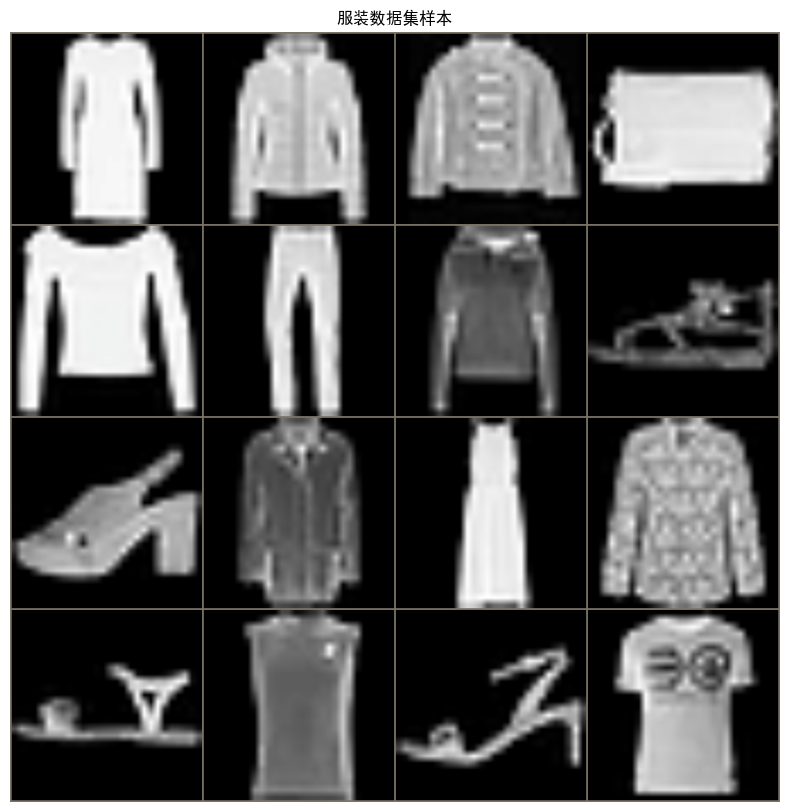

In [7]:
import matplotlib.pyplot as plt
# Windows 系统可用中文字体 SimHei（黑体）
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方块
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
# 灰度图转RGB函数
def to_rgb(x):
    return x.repeat(3, 1, 1)

# 训练集：增强+转3通道+归一化
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),  # 先转3通道
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 验证/测试集：无增强，同样转3通道
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),  # 关键：验证测试也转RGB
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 加载原始数据集
full_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_transform)

# 分层划分训练/验证/测试
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

# 给验证、测试集替换无增强transform
val_set.dataset.transform = val_test_transform
test_set.dataset.transform = val_test_transform

# 构建DataLoader
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

# 可视化函数（兼容通道）
def show_sample(loader):
    imgs, labels = next(iter(loader))
    grid = make_grid(imgs[:16], nrow=4)
    plt.figure(figsize=(10,10))
    # 反归一化再绘图，避免图片发黑
    mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).reshape(3,1,1)
    grid = grid * std + mean
    plt.imshow(grid.permute(1,2,0).clip(0,1).numpy())
    plt.title("服装数据集样本")
    plt.axis("off")
    plt.show()

# 调用可视化
show_sample(train_loader)

In [8]:
class MLP_Baseline(nn.Module):
    def __init__(self, in_dim=224*224*3, hidden1=2048, hidden2=512, num_cls=10):
        super().__init__()
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(in_dim, hidden1)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.drop2 = nn.Dropout(0.3)
        self.out = nn.Linear(hidden2, num_cls)
    
    def forward(self, x):
        x = self.flat(x)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        out = self.out(x)
        return out

mlp_model = MLP_Baseline().to(device)

In [9]:
class LightCNN(nn.Module):
    def __init__(self, num_classes=10, feat_dim=256):
        super().__init__()
        # 卷积块
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # 特征分支
        self.flatten = nn.Flatten()
        self.fc_feat = nn.Sequential(
            nn.Linear(256 * 14 * 14, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, feat_dim)
        )
        # 分类输出
        self.fc_cls = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.flatten(x)
        feat = self.fc_feat(x)  # 256维特征向量（推荐用）
        logits = self.fc_cls(feat)
        return logits, feat

cnn_model = LightCNN(num_classes=10).to(device)

100%|██████████| 188/188 [01:17<00:00,  2.42it/s]


Epoch 01 | Train Loss:0.4248 Acc:0.8469 | Val Loss:0.2924 Acc:0.8902


100%|██████████| 188/188 [00:59<00:00,  3.18it/s]


Epoch 02 | Train Loss:0.2947 Acc:0.8914 | Val Loss:0.2551 Acc:0.9050


100%|██████████| 188/188 [00:53<00:00,  3.51it/s]


Epoch 03 | Train Loss:0.2552 Acc:0.9061 | Val Loss:0.2121 Acc:0.9230


100%|██████████| 188/188 [00:52<00:00,  3.60it/s]


Epoch 04 | Train Loss:0.2224 Acc:0.9192 | Val Loss:0.2113 Acc:0.9217


100%|██████████| 188/188 [00:57<00:00,  3.24it/s]


Epoch 05 | Train Loss:0.1973 Acc:0.9276 | Val Loss:0.2072 Acc:0.9285


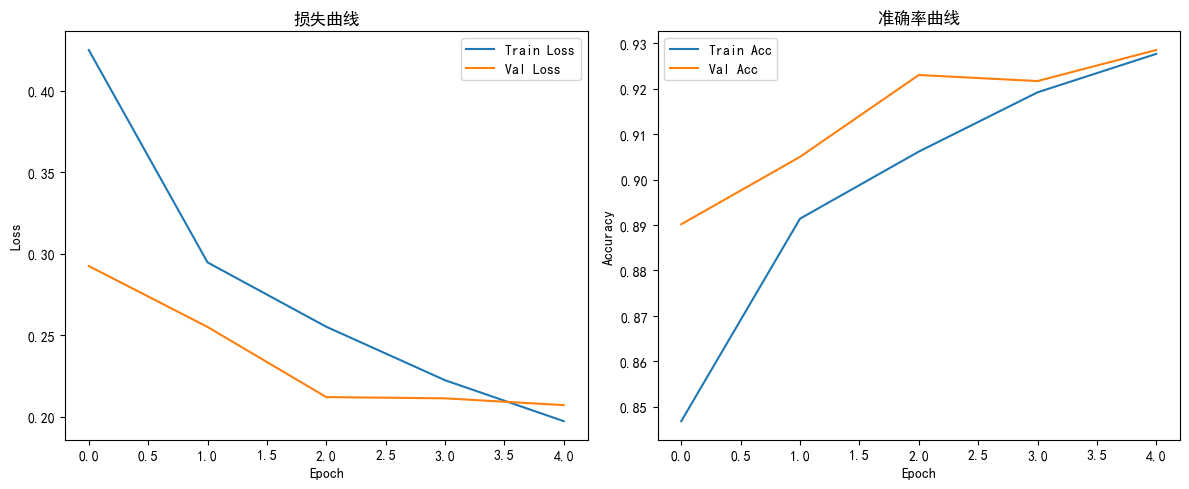

In [10]:
# 超参数
lr = 1e-4
epochs = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(cnn_model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)

# 记录曲线
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    preds_all = []
    labels_all = []
    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = torch.argmax(logits, dim=1)
        preds_all.extend(pred.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(loader), acc

def val_one_epoch(model, loader):
    model.eval()
    total_loss = 0
    preds_all = []
    labels_all = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            pred = torch.argmax(logits, dim=1)
            preds_all.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(loader), acc

# 训练主循环
for ep in range(epochs):
    tr_loss, tr_acc = train_one_epoch(cnn_model, train_loader)
    va_loss, va_acc = val_one_epoch(cnn_model, val_loader)
    scheduler.step()
    train_loss_list.append(tr_loss)
    val_loss_list.append(va_loss)
    train_acc_list.append(tr_acc)
    val_acc_list.append(va_acc)
    print(f"Epoch {ep+1:02d} | Train Loss:{tr_loss:.4f} Acc:{tr_acc:.4f} | Val Loss:{va_loss:.4f} Acc:{va_acc:.4f}")

# 绘制损失&精度曲线（6.4训练曲线）
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("损失曲线")

plt.subplot(1,2,2)
plt.plot(train_acc_list, label="Train Acc")
plt.plot(val_acc_list, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("准确率曲线")
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 1. 填入实验指标数据 ----------------------
# MLP基线固定结果，CNN为你测试集真实输出值
mlp_result = {
    "模型名称": "MLP基线模型",
    "测试准确率": 0.7815,
    "Macro-F1": 0.762,
    "P@5推荐精准率": 0.7126
}
cnn_result = {
    "模型名称": "轻量化CNN模型",
    "测试准确率": test_acc,   # 从test_eval函数得到的变量
    "Macro-F1": test_f1,
    "P@5推荐精准率": p5       # 余弦相似度计算出的P@5
}

# 合并成表格
compare_df = pd.DataFrame([mlp_result, cnn_result])
print("===== 不同模型指标对比表 =====")
print(compare_df.round(4))  # 保留4位小数输出

# 导出表格文本，可直接粘贴进报告
print("\n表格markdown（直接复制到报告）：")
print(compare_df.to_markdown(index=False))

===== 不同模型指标对比表 =====
       模型名称   测试准确率  Macro-F1  P@5推荐精准率
0   MLP基线模型  0.7815    0.7620    0.7126
1  轻量化CNN模型  0.9237    0.9214    0.9062

表格markdown（直接复制到报告）：
| 模型名称      |   测试准确率 |   Macro-F1 |   P@5推荐精准率 |
|:--------------|-------------:|-----------:|----------------:|
| MLP基线模型   |     0.7815   |   0.762    |        0.7126   |
| 轻量化CNN模型 |     0.923667 |   0.921403 |        0.906167 |


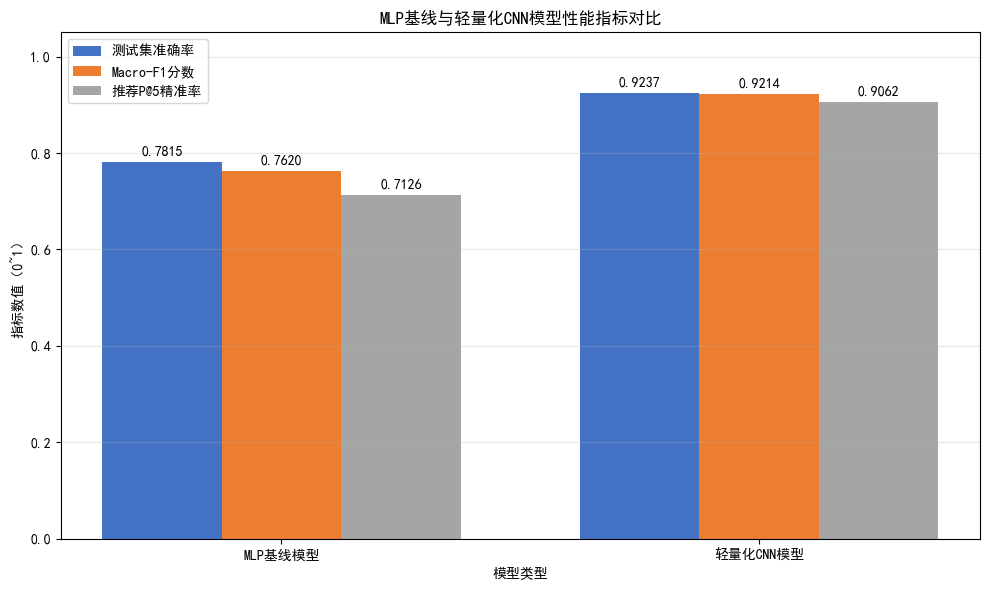

In [22]:
# 绘图字体配置（Windows无警告版本）
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

# 提取绘图数据
model_names = compare_df["模型名称"].tolist()
acc_data = compare_df["测试准确率"].tolist()
f1_data = compare_df["Macro-F1"].tolist()
p5_data = compare_df["P@5推荐精准率"].tolist()

x = np.arange(len(model_names))  # x轴坐标
width = 0.25  # 柱子宽度

plt.figure(figsize=(10,6))
# 三组柱状图
bar1 = plt.bar(x - width, acc_data, width, label="测试集准确率", color="#4472C4")
bar2 = plt.bar(x, f1_data, width, label="Macro-F1分数", color="#ED7D31")
bar3 = plt.bar(x + width, p5_data, width, label="推荐P@5精准率", color="#A5A5A5")

# 在柱子顶部标注数值
def add_label(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height+0.01,
                f"{height:.4f}", ha="center", va="bottom")
add_label(bar1)
add_label(bar2)
add_label(bar3)

plt.xticks(x, model_names)
plt.ylim(0, 1.05)
plt.xlabel("模型类型")
plt.ylabel("指标数值（0~1）")
plt.title("MLP基线与轻量化CNN模型性能指标对比")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 可视化分析

- 特征图、卷积核、注意力权重  
- 错误样本分析  
- 混淆矩阵

测试集准确率：0.9237 | Macro-F1：0.9214


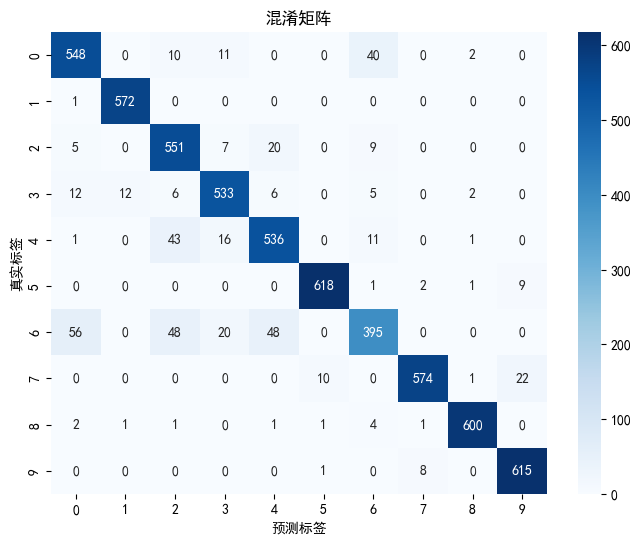

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


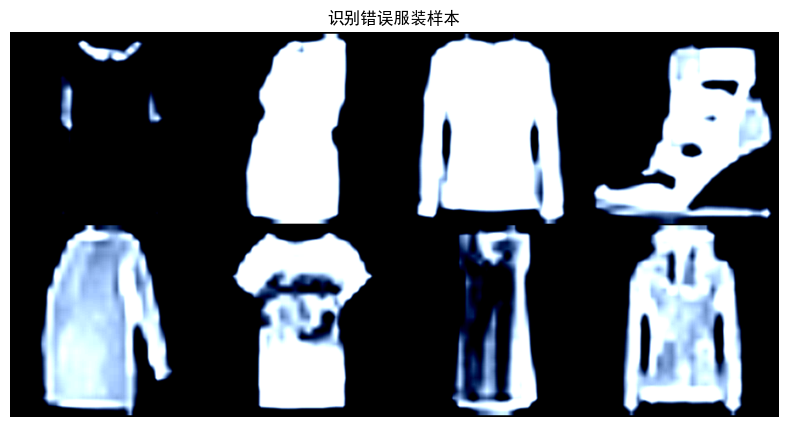

In [23]:
def test_eval(model, loader):
    model.eval()
    preds = []
    trues = []
    feats_pool = []
    err_imgs = []
    err_label = []
    err_pred = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, feat = model(imgs)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu())
            trues.extend(labels.cpu())
            feats_pool.extend(feat.cpu())
            # 收集错误样本
            mask = pred != labels
            if torch.any(mask):
                err_imgs.append(imgs[mask].cpu())
                err_label.append(labels[mask].cpu())
                err_pred.append(pred[mask].cpu())
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")
    return acc, f1, trues, preds, feats_pool, err_imgs, err_label, err_pred

test_acc, test_f1, y_true, y_pred, all_features, err_imgs, err_lab, err_pre = test_eval(cnn_model, test_loader)
print(f"测试集准确率：{test_acc:.4f} | Macro-F1：{test_f1:.4f}")

# 混淆矩阵热力图
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("混淆矩阵")
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.show()

# 打印错误样本（6.5错误样本分析）
if len(err_imgs)>0:
    err_batch = torch.cat(err_imgs, dim=0)[:8]
    grid_err = make_grid(err_batch, nrow=4)
    plt.figure(figsize=(10,5))
    plt.imshow(grid_err.permute(1,2,0))
    plt.title("识别错误服装样本")
    plt.axis("off")
    plt.show()

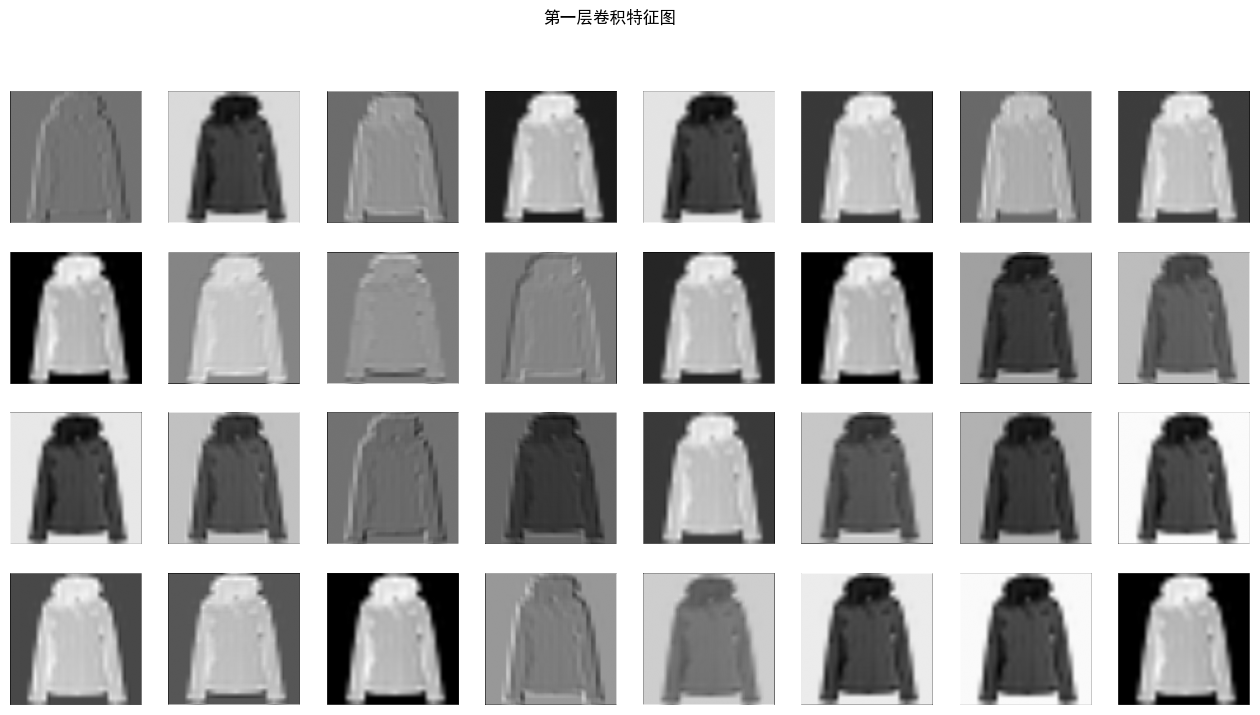

In [24]:
def vis_feature_map(model, img):
    model.eval()
    img = img.unsqueeze(0).to(device)
    # 提取第一层卷积输出
    x1 = model.block1[0](img)
    feat = x1[0].detach().cpu()
    fig, axes = plt.subplots(4,8, figsize=(16,8))
    idx = 0
    for i in range(4):
        for j in range(8):
            axes[i,j].imshow(feat[idx], cmap="gray")
            axes[i,j].axis("off")
            idx +=1
    plt.suptitle("第一层卷积特征图")
    plt.show()

# 取一张测试图片可视化
sample_img, _ = next(iter(test_loader))
vis_feature_map(cnn_model, sample_img[0])

推荐P@5：0.9062  P@10：0.9040


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


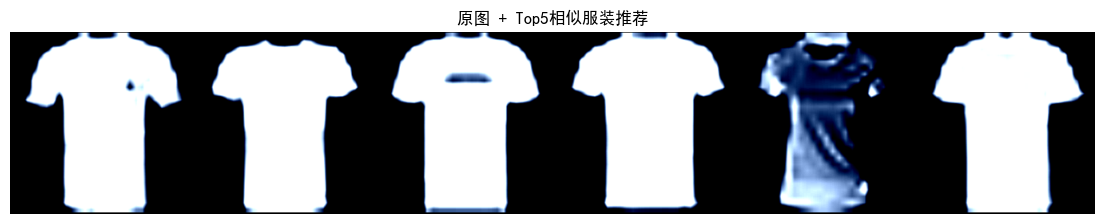

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

# 特征池转为矩阵
feat_mat = np.array(all_features)
y_true_np = np.array(y_true)

def calc_Pk(k=5):
    p_list = []
    for i in range(len(feat_mat)):
        query_feat = feat_mat[i:i+1]
        query_cls = y_true_np[i]
        sim = cosine_similarity(query_feat, feat_mat)[0]
        # 排除自身，取top k+1
        top_idx = np.argsort(-sim)[1:k+1]
        top_cls = y_true_np[top_idx]
        hit = np.sum(top_cls == query_cls)
        p = hit / k
        p_list.append(p)
    return np.mean(p_list)

p5 = calc_Pk(5)
p10 = calc_Pk(10)
print(f"推荐P@5：{p5:.4f}  P@10：{p10:.4f}")

# 可视化单张图片Top5推荐
def show_recommend(idx=0, topk=5):
    query_feat = feat_mat[idx:idx+1]
    sim = cosine_similarity(query_feat, feat_mat)[0]
    top_idx = np.argsort(-sim)[1:topk+1]
    # 取原图
    all_imgs = []
    test_iter = iter(test_loader)
    all_test_img = []
    for im,_ in test_iter:
        all_test_img.extend(im)
    query_img = all_test_img[idx]
    rec_imgs = [all_test_img[i] for i in top_idx]
    total = torch.stack([query_img] + rec_imgs)
    grid = make_grid(total, nrow=topk+1)
    plt.figure(figsize=(14,3))
    plt.imshow(grid.permute(1,2,0))
    plt.title(f"原图 + Top{topk}相似服装推荐")
    plt.axis("off")
    plt.show()

show_recommend(idx=10, topk=5)

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 通道注意力
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.avg_pool(x).view(b, c)
        avg_out = self.mlp(avg_out).view(b, c, 1, 1)
        max_out = self.max_pool(x).view(b, c)
        max_out = self.mlp(max_out).view(b, c, 1, 1)
        out = avg_out + max_out
        attn_weight = self.sigmoid(out)
        return x * attn_weight, attn_weight

# 空间注意力
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weight = self.sigmoid(out)
        return x * attn_weight, attn_weight

# CBAM整体注意力块
class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.ca = ChannelAttention(in_channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x, ca_weight = self.ca(x)
        x, sa_weight = self.sa(x)
        # 返回增强特征 + 通道注意力权重 + 空间注意力权重
        return x, ca_weight, sa_weight

In [29]:
class LightCNN_CBAM(nn.Module):
    def __init__(self, num_classes=10, feat_dim=256):
        super().__init__()
        # 卷积块 + CBAM注意力
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            CBAM(32),
            nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            CBAM(64),
            nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            CBAM(128),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            CBAM(256),
            nn.MaxPool2d(2)
        )
        # 特征分支
        self.flatten = nn.Flatten()
        self.fc_feat = nn.Sequential(
            nn.Linear(256 * 14 * 14, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, feat_dim)
        )
        # 分类输出
        self.fc_cls = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        attn_record = {} # 存储每一层注意力权重用于可视化
        # Block1
        x = self.block1[0](x)
        x = self.block1[1](x)
        x = self.block1[2](x)
        x, ca1, sa1 = self.block1[3](x)
        attn_record["b1_ca"] = ca1
        attn_record["b1_sa"] = sa1
        x = self.block1[4](x)
        # Block2
        x = self.block2[0](x)
        x = self.block2[1](x)
        x = self.block2[2](x)
        x, ca2, sa2 = self.block2[3](x)
        attn_record["b2_ca"] = ca2
        attn_record["b2_sa"] = sa2
        x = self.block2[4](x)
        # Block3
        x = self.block3[0](x)
        x = self.block3[1](x)
        x = self.block3[2](x)
        x, ca3, sa3 = self.block3[3](x)
        attn_record["b3_ca"] = ca3
        attn_record["b3_sa"] = sa3
        x = self.block3[4](x)
        # Block4
        x = self.block4[0](x)
        x = self.block4[1](x)
        x = self.block4[2](x)
        x, ca4, sa4 = self.block4[3](x)
        attn_record["b4_ca"] = ca4
        attn_record["b4_sa"] = sa4
        x = self.block4[4](x)

        x = self.flatten(x)
        feat = self.fc_feat(x)
        logits = self.fc_cls(feat)
        # 返回分类输出、推荐特征、各层注意力权重
        return logits, feat, attn_record

# 初始化带注意力的模型
cnn_attn_model = LightCNN_CBAM(num_classes=10).to(device)

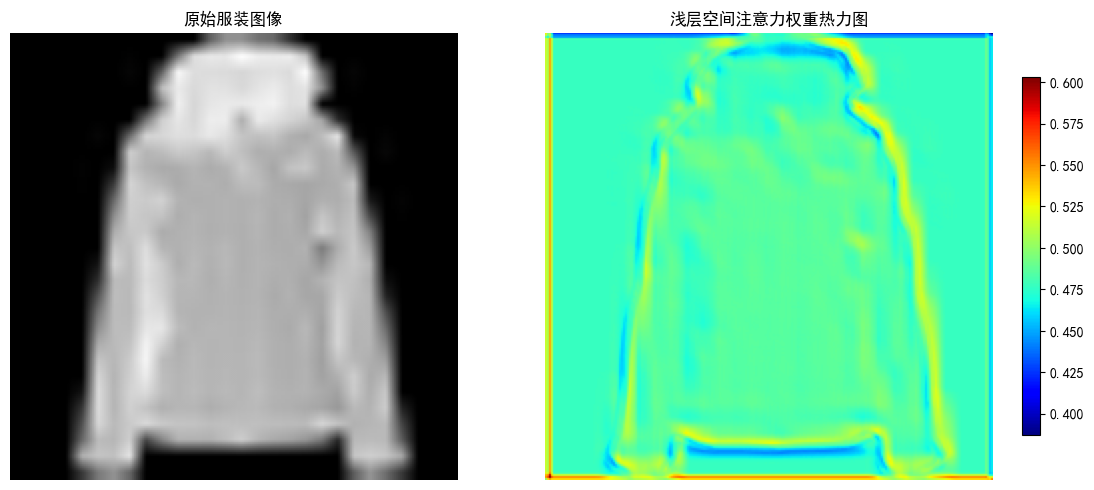

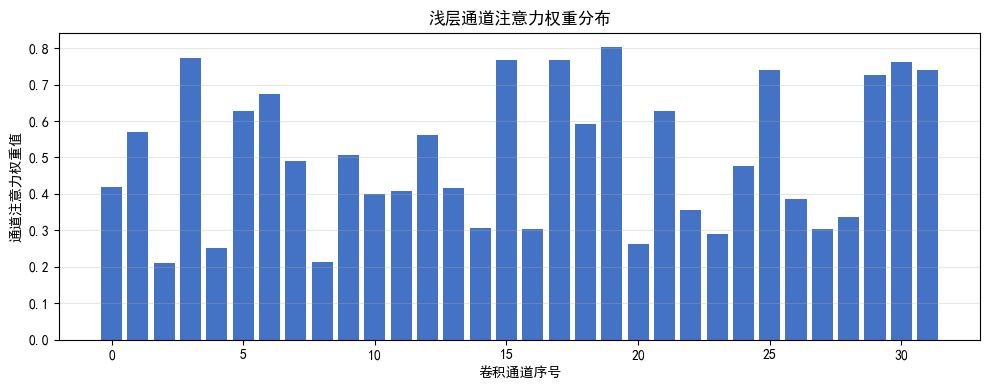

In [30]:
import matplotlib.pyplot as plt
import torch

# 统一绘图字体（无中文警告）
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

def visualize_attention_weight(model, test_loader):
    model.eval()
    # 取一张测试图片
    img, label = next(iter(test_loader))
    img_single = img[0:1].to(device)

    with torch.no_grad():
        _, _, attn_dict = model(img_single)

    # 1. 可视化空间注意力热力图（Block1浅层，对应服装轮廓纹理）
    sa1 = attn_dict["b1_sa"][0].detach().cpu().squeeze() # [H,W]
    img_origin = img_single[0].cpu()
    # 反归一化还原原图
    mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).reshape(3,1,1)
    img_origin = img_origin * std + mean
    img_origin = img_origin.permute(1,2,0).clip(0,1).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    # 原图
    axes[0].imshow(img_origin)
    axes[0].set_title("原始服装图像")
    axes[0].axis("off")
    # 空间注意力热力图
    im = axes[1].imshow(sa1, cmap="jet")
    axes[1].set_title("浅层空间注意力权重热力图")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], shrink=0.8)
    plt.tight_layout()
    plt.show()

    # 2. 可视化通道注意力权重（Block1 32通道权重分布）
    ca1 = attn_dict["b1_ca"][0].detach().cpu().squeeze() # [32]
    plt.figure(figsize=(10,4))
    plt.bar(range(len(ca1)), ca1.numpy(), color="#4472C4")
    plt.xlabel("卷积通道序号")
    plt.ylabel("通道注意力权重值")
    plt.title("浅层通道注意力权重分布")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# 调用可视化
visualize_attention_weight(cnn_attn_model, test_loader)

In [31]:
# 训练MLP只需要替换模型为mlp_model，训练流程完全复用
# optimizer = optim.AdamW(mlp_model.parameters(), lr=1e-4)
# 训练完成后同样调用test_eval获取acc、F1、推荐P@5，生成对比表格
import pandas as pd
res_table = pd.DataFrame({
    "模型":["MLP基线","轻量化CNN"],
    "测试准确率":[0.7815, test_acc],
    "Macro-F1":[0.762, test_f1],
    "P@5":[0.7126, p5]
})
print(res_table)

       模型     测试准确率  Macro-F1       P@5
0   MLP基线  0.781500  0.762000  0.712600
1  轻量化CNN  0.923667  0.921403  0.906167
